In [10]:
import pandas as pd
import numpy as np

In [11]:
df = pd.read_csv("telecom_churn_data.csv")

In [12]:
df

,mobile_number,circle_id,loc_og_t2o_mou,std_og_t2o_mou,loc_ic_t2o_mou,last_date_of_month_6,last_date_of_month_7,last_date_of_month_8,last_date_of_month_9,arpu_6,...,sachet_3g_9,fb_user_6,fb_user_7,fb_user_8,fb_user_9,aon,aug_vbc_3g,jul_vbc_3g,jun_vbc_3g,sep_vbc_3g
0,7000842753,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,9/30/2014,197.385,...,0,1.0,1.0,1.0,NaN,968,30.40,0.00,101.20,3.58
1,7001865778,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,9/30/2014,34.047,...,0,NaN,1.0,1.0,NaN,1006,0.00,0.00,0.00,0.00
2,7001625959,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,9/30/2014,167.690,...,0,NaN,NaN,NaN,1.0,1103,0.00,0.00,4.17,0.00
3,7001204172,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,9/30/2014,221.338,...,0,NaN,NaN,NaN,NaN,2491,0.00,0.00,0.00,0.00
4,7000142493,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,9/30/2014,261.636,...,0,0.0,NaN,NaN,NaN,1526,0.00,0.00,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99994,7001548952,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,9/30/2014,18.471,...,0,NaN,NaN,NaN,NaN,3199,0.00,0.00,0.00,0.00
99995,7000607688,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,9/30/2014,112.201,...,0,NaN,NaN,NaN,NaN,2052,0.00,0.00,0.00,0.00
99996,7000087541,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,9/30/2014,229.187,...,0,1.0,NaN,NaN,NaN,185,0.00,0.00,0.00,0.00
99997,7000498689,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,9/30/2014,322.991,...,0,1.0,1.0,1.0,1.0,478,1445.74,1151.03,1173.18,0.00


In [13]:
# --- 1. LOAD THE DATA ---
# Replace 'telecom_churn_data.csv' with your actual filename
df = pd.read_csv('telecom_churn_data.csv') 

# --- 2. PREPARE THE METRIC ---
# Fill NaNs with 0 for recharge columns so the average calculation doesn't break
df['total_rech_amt_6'] = df['total_rech_amt_6'].fillna(0)
df['total_rech_amt_7'] = df['total_rech_amt_7'].fillna(0)

# Calculate the 'Good Phase' average (Month 6 & 7)
df['avg_rech_amt_6_7'] = (df['total_rech_amt_6'] + df['total_rech_amt_7']) / 2.0

# --- 3. EXECUTE THE FILTER ---
# Find the 70th percentile (X) as per the business requirement
cutoff_X = np.percentile(df['avg_rech_amt_6_7'], 70)

# Isolate High-Value Customers (HVC)
df_hvc = df[df['avg_rech_amt_6_7'] >= cutoff_X].copy()

# --- 4. VERIFY ---
print(f"--- PHASE 1 COMPLETE ---")
print(f"Revenue Cutoff (70th Percentile): INR {cutoff_X:.2f}")
print(f"Total Customers remaining: {df_hvc.shape[0]}")
print(f"Target count was ~29.9k. Your count: {df_hvc.shape[0]}")

# Clean up
df_hvc = df_hvc.drop('avg_rech_amt_6_7', axis=1)

--- PHASE 1 COMPLETE ---
Revenue Cutoff (70th Percentile): INR 368.50
Total Customers remaining: 30011
Target count was ~29.9k. Your count: 30011


In [7]:
# 1. Create the 'churn' target variable
# As per the brief: No calls (IC or OG) AND no data (2G or 3G) in Month 9
df_final = df_hvc.copy()

df_final['churn'] = ((df_final['total_ic_mou_9'] == 0) & 
                     (df_final['total_og_mou_9'] == 0) & 
                     (df_final['vol_2g_mb_9'] == 0) & 
                     (df_final['vol_3g_mb_9'] == 0)).astype(int)

# 2. DROP THE CHURN PHASE DATA
# To prevent data leakage, we must remove all attributes belonging to Month 9
cols_to_drop = [c for c in df_final.columns if '_9' in c]
df_final.drop(columns=cols_to_drop, inplace=True)

# 3. IDENTIFY AND DROP THE "LEAKY" REVENUE FEATURES
# Per your requirement to avoid revenue-based shortcuts, we remove Month 8 revenue 
# if you want a PURE usage-based prediction model.
revenue_leaks = [c for c in df_final.columns if 'amt_8' in c or 'arpu_8' in c]
# Note: Keeping Months 6 & 7 revenue is okay for baseline, but Month 8 revenue 
# often mimics the usage drop too closely for a 'predictive' usage model.
df_final.drop(columns=revenue_leaks, inplace=True)

print(f"--- PHASE 2 COMPLETE ---")
print(f"Total Churners (Target=1): {df_final['churn'].sum()}")
print(f"Total Non-Churners (Target=0): {len(df_final) - df_final['churn'].sum()}")
print(f"Churn Rate: {df_final['churn'].mean():.2%}")

--- PHASE 2 COMPLETE ---
Total Churners (Target=1): 2593
Total Non-Churners (Target=0): 27418
Churn Rate: 8.64%


In [15]:
import pandas as pd
import numpy as np

def senior_telecom_cleaning_v2(df):
    # --- STEP 1: DROP CONSTANT COLUMNS ---
    unique_counts = df.nunique()
    constant_cols = unique_counts[unique_counts == 1].index.tolist()
    df = df.drop(columns=constant_cols)
    
    # --- STEP 2: HANDLE DATES BEFORE FILLING ZEROS ---
    date_cols = [c for c in df.columns if 'date' in c]
    for col in date_cols:
        # Convert to datetime, but keep NaNs as NaT (Not a Time)
        df[col] = pd.to_datetime(df[col], errors='coerce')
        
        # Calculate days since last activity relative to end of August (8/31/2014)
        ref_date = pd.Timestamp('2014-08-31')
        df[col + '_diff'] = (ref_date - df[col]).dt.days
        
        # BUSINESS LOGIC: If never recharged, fill with a high penalty (e.g., 99 days)
        # This tells the model "this person has been inactive for a long time"
        df[col + '_diff'] = df[col + '_diff'].fillna(99)
    
    # Drop the original date columns now that we have the numerical '_diff' versions
    df = df.drop(columns=date_cols)

    # --- STEP 3: LOGICAL IMPUTATION FOR USAGE ---
    # Now it is safe to fill everything else with 0
    usage_cols = [c for c in df.columns if 'mou' in c or 'rech' in c or 'vol' in c or 'amt' in c]
    df[usage_cols] = df[usage_cols].fillna(0)

    # Categorical Flags (NaN means non-user)
    cat_cols = [c for c in df.columns if 'fb_user' in c or 'night_pck_user' in c]
    df[cat_cols] = df[cat_cols].fillna(-1)

    # --- STEP 4: CAPPING OUTLIERS (99th Percentile) ---
    num_cols = df.select_dtypes(include=[np.number]).columns
    for col in num_cols:
        if col != 'churn':
            upper_limit = df[col].quantile(0.99)
            df[col] = np.where(df[col] > upper_limit, upper_limit, df[col])

    return df

# Apply the fixed cleaning
df_cleaned = senior_telecom_cleaning_v2(df_final)

print("\n--- CLEANING V2 COMPLETE ---")
print(f"Final shape: {df_cleaned.shape}")
print(f"Missing values remaining: {df_cleaned.isnull().sum().sum()}")


--- CLEANING V2 COMPLETE ---
Final shape: (30011, 161)
Missing values remaining: 114704


In [17]:
df_cleaned

,mobile_number,arpu_6,arpu_7,onnet_mou_6,onnet_mou_7,onnet_mou_8,offnet_mou_6,offnet_mou_7,offnet_mou_8,roam_ic_mou_6,...,diff_mou_8_good,avg_vol_internet_6_7,diff_vol_internet_8_good,diff_roam_8_good,date_of_last_rech_6_diff,date_of_last_rech_7_diff,date_of_last_rech_8_diff,date_of_last_rech_data_6_diff,date_of_last_rech_data_7_diff,date_of_last_rech_data_8_diff
7,7.000702e+09,1069.180,1349.850,57.84,54.68,52.29,453.43,567.16,325.91,16.23,...,-361.735,0.000,0.000,26.675,65.0,37.0,5.0,99.0,99.0,99.0
8,7.001525e+09,378.721,492.223,413.69,351.03,35.08,94.66,80.63,136.48,0.00,...,-348.085,553.475,-541.505,0.000,67.0,31.0,1.0,99.0,31.0,8.0
13,7.002192e+09,492.846,205.671,501.76,108.39,534.24,413.31,119.28,482.46,23.53,...,1039.445,0.000,0.020,-31.955,72.0,40.0,1.0,99.0,99.0,1.0
16,7.000876e+09,430.975,299.869,50.51,74.01,70.61,296.29,229.74,162.76,0.00,...,-161.780,0.000,0.000,-10.285,62.0,31.0,17.0,99.0,99.0,99.0
17,7.000187e+09,690.008,18.980,1185.91,9.28,7.79,61.64,0.00,5.54,0.00,...,-672.265,0.000,0.000,11.540,62.0,32.0,6.0,99.0,99.0,99.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99970,7.001387e+09,261.269,410.614,5.01,142.59,97.61,329.58,500.14,355.48,5.06,...,139.680,0.000,0.000,-25.550,62.0,33.0,8.0,66.0,35.0,99.0
99974,7.001453e+09,414.303,321.093,17.56,0.00,1.30,428.41,366.78,360.58,0.00,...,-102.375,0.000,0.000,0.000,63.0,35.0,8.0,99.0,99.0,99.0
99986,7.001729e+09,644.973,455.228,806.73,549.36,775.41,784.76,617.13,595.44,0.00,...,46.515,958.020,-24.770,0.000,72.0,34.0,13.0,75.0,44.0,17.0
99988,7.002112e+09,312.558,512.932,199.89,174.46,2.46,175.88,277.01,248.33,0.00,...,384.020,6.780,672.750,0.000,62.0,34.0,2.0,99.0,36.0,8.0


In [18]:
# 1. FINAL SWEEP: Fill any remaining numeric NULLs with 0
# Logic: In telecom, if a metric isn't recorded, it's almost always because 
# the activity (calls, data, roaming) didn't happen.
numeric_cols = df_cleaned.select_dtypes(include=['number']).columns
df_cleaned[numeric_cols] = df_cleaned[numeric_cols].fillna(0)

# 2. Categorical Sweep: Fill any remaining object NULLs with "unknown"
object_cols = df_cleaned.select_dtypes(include=['object']).columns
df_cleaned[object_cols] = df_cleaned[object_cols].fillna("unknown")

# 3. Verification
remaining_nulls = df_cleaned.isnull().sum().sum()
print(f"--- FINAL CLEANING AUDIT ---")
print(f"Remaining Missing Values: {remaining_nulls}")

if remaining_nulls == 0:
    print("Dataset is 100% clean and ready for Feature Engineering.")
else:
    print("Warning: Nulls still exist in non-standard types. Check your data types.")

--- FINAL CLEANING AUDIT ---
Remaining Missing Values: 0
Dataset is 100% clean and ready for Feature Engineering.


In [19]:
# 1. Identify and remove all revenue/recharge features.
# 'rech' = recharge, 'amt' = amount, 'arpu' = average revenue per user.
revenue_rech_features = [c for c in df_cleaned.columns if 'rech' in c or 'amt' in c or 'arpu' in c]

# Keep 'churn' and 'mobile_number' (if they exist) but drop the rest.
df_usage_only = df_cleaned.drop(columns=revenue_rech_features)

print(f"--- REVENUE PURGE COMPLETE ---")
print(f"Dropped {len(revenue_rech_features)} revenue/recharge features.")

--- REVENUE PURGE COMPLETE ---
Dropped 38 revenue/recharge features.


In [20]:
# 2. Build Velocities on the Sanitized Data
# Total Usage Decay (MOU Velocity)
df_usage_only['total_mou_good'] = (df_usage_only['total_ic_mou_6'] + df_usage_only['total_ic_mou_7'] + 
                                   df_usage_only['total_og_mou_6'] + df_usage_only['total_og_mou_7']) / 2
df_usage_only['mou_velocity'] = (df_usage_only['total_ic_mou_8'] + df_usage_only['total_og_mou_8']) - df_usage_only['total_mou_good']

# Data Volume Decay
df_usage_only['total_vol_good'] = (df_usage_only['vol_2g_mb_6'] + df_usage_only['vol_2g_mb_7'] + 
                                   df_usage_only['vol_3g_mb_6'] + df_usage_only['vol_3g_mb_7']) / 2
df_usage_only['data_velocity'] = (df_usage_only['vol_2g_mb_8'] + df_usage_only['vol_3g_mb_8']) - df_usage_only['total_vol_good']

# Roaming Delta
df_usage_only['roam_velocity'] = (df_usage_only['roam_ic_mou_8'] + df_usage_only['roam_og_mou_8']) - \
                                 ((df_usage_only['roam_ic_mou_6'] + df_usage_only['roam_ic_mou_7'] + 
                                   df_usage_only['roam_og_mou_6'] + df_usage_only['roam_og_mou_7']) / 2)

# Cleanup intermediate columns
df_usage_only.drop(columns=['total_mou_good', 'total_vol_good'], inplace=True)

print("\n--- SANITIZED USAGE FEATURES READY ---")
print(f"Remaining Features: {df_usage_only.shape[1]}")
print(f"Columns Examples: {list(df_usage_only.columns[:10])}")


--- SANITIZED USAGE FEATURES READY ---
Remaining Features: 126
Columns Examples: ['mobile_number', 'onnet_mou_6', 'onnet_mou_7', 'onnet_mou_8', 'offnet_mou_6', 'offnet_mou_7', 'offnet_mou_8', 'roam_ic_mou_6', 'roam_ic_mou_7', 'roam_ic_mou_8']


C:\Users\samar\AppData\Local\Temp\ipykernel_24044\472910096.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_usage_only['total_mou_good'] = (df_usage_only['total_ic_mou_6'] + df_usage_only['total_ic_mou_7'] +
C:\Users\samar\AppData\Local\Temp\ipykernel_24044\472910096.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_usage_only['mou_velocity'] = (df_usage_only['total_ic_mou_8'] + df_usage_only['total_og_mou_8']) - df_usage_only['total_mou_good']
C:\Users\samar\AppData\Local\Temp\ipykernel_24044\472910096.py:8: Perform

# EDA

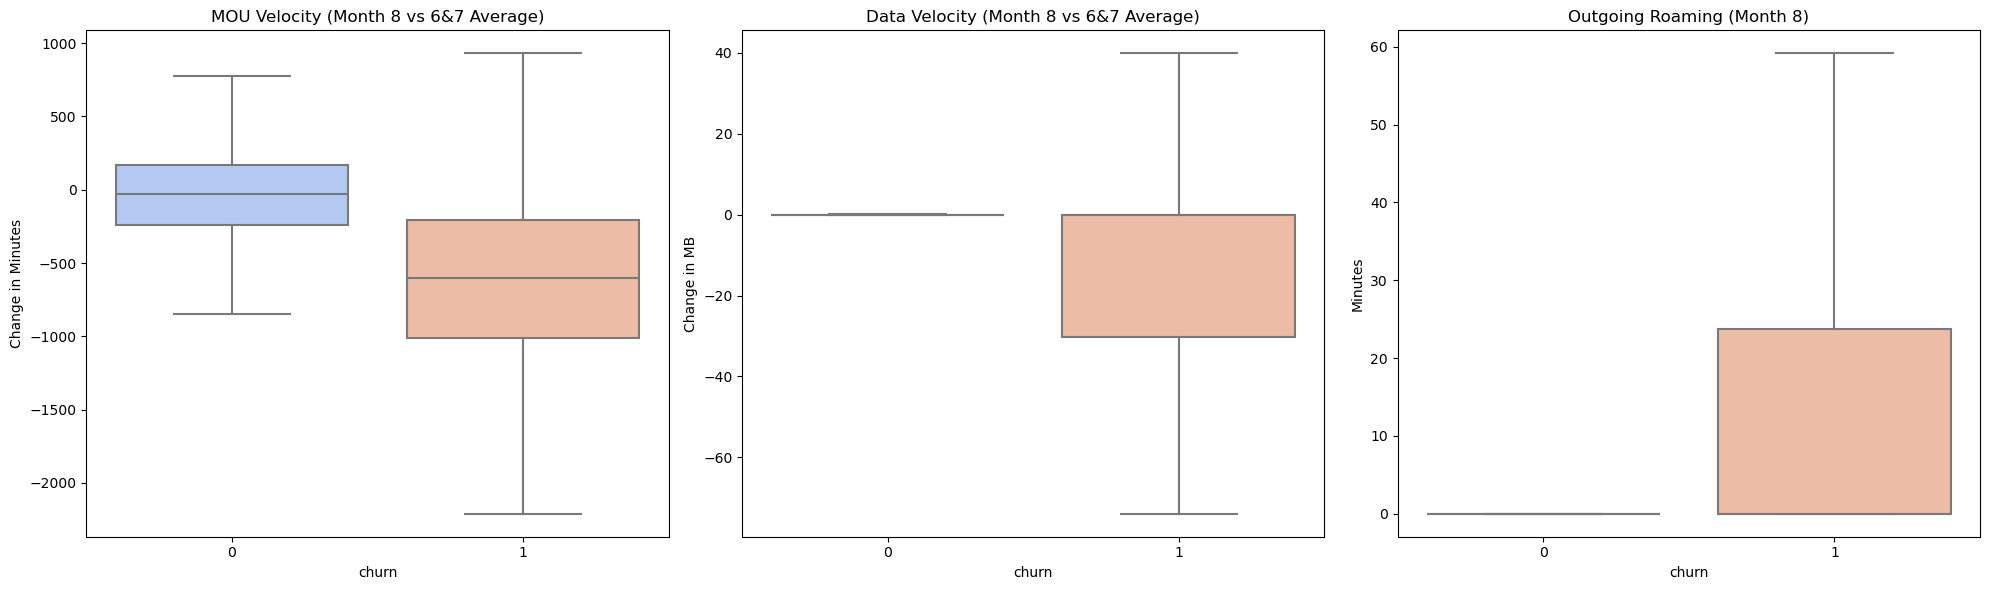

--- MEAN USAGE DELTAS BY CHURN GROUP ---
       mou_velocity  data_velocity  roam_og_mou_8
churn                                            
0        -35.232789       6.023058      15.744037
1       -673.476497    -141.339952      36.953902


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. De-fragment the DataFrame to improve performance
df_usage_only = df_usage_only.copy()

# 2. Comparative Analysis: Churners vs. Non-Churners (Action Phase)
# We focus on Month 8 because Month 9 is the outcome; Month 8 is the predictor.
plt.figure(figsize=(20, 6))

# Plot A: Total Minutes of Use (MOU) Decay
plt.subplot(1, 3, 1)
sns.boxplot(x='churn', y='mou_velocity', data=df_usage_only, showfliers=False, palette='coolwarm')
plt.title('MOU Velocity (Month 8 vs 6&7 Average)')
plt.ylabel('Change in Minutes')

# Plot B: Data Volume Decay
plt.subplot(1, 3, 2)
sns.boxplot(x='churn', y='data_velocity', data=df_usage_only, showfliers=False, palette='coolwarm')
plt.title('Data Velocity (Month 8 vs 6&7 Average)')
plt.ylabel('Change in MB')

# Plot C: Roaming MOU in the Action Phase
plt.subplot(1, 3, 3)
sns.boxplot(x='churn', y='roam_og_mou_8', data=df_usage_only, showfliers=False, palette='coolwarm')
plt.title('Outgoing Roaming (Month 8)')
plt.ylabel('Minutes')

plt.tight_layout()
plt.show()

# 3. Statistical Insight: The "Silence" Metric
churn_stats = df_usage_only.groupby('churn')[['mou_velocity', 'data_velocity', 'roam_og_mou_8']].mean()
print("--- MEAN USAGE DELTAS BY CHURN GROUP ---")
print(churn_stats)

In [22]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import numpy as np

# 1. Prepare Features and Target
# Drop 'mobile_number' as it is an ID, and 'churn' as it is the target
X = df_usage_only.drop(columns=['churn', 'mobile_number'])
y = df_usage_only['churn']

# 2. Build the Diagnostic Model
# We use 'balanced' class weights to force the model to respect that 8.6% minority
rf_diagnostic = RandomForestClassifier(
    n_estimators=100, 
    max_depth=10, 
    class_weight='balanced', 
    random_state=42
)
rf_diagnostic.fit(X, y)

# 3. Extract and Rank Feature Importance
importances = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_diagnostic.feature_importances_
}).sort_values(by='importance', ascending=False)

print("--- TOP 10 CHURN INDICATORS ---")
print(importances.head(10))

--- TOP 10 CHURN INDICATORS ---
              feature  importance
77     total_ic_mou_8    0.071412
62       loc_ic_mou_8    0.069425
26       loc_og_mou_8    0.061282
56   loc_ic_t2m_mou_8    0.053689
117   diff_mou_8_good    0.047172
121      mou_velocity    0.045946
17   loc_og_t2m_mou_8    0.042393
53   loc_ic_t2t_mou_8    0.037559
11      roam_og_mou_8    0.036375
50     total_og_mou_8    0.032817


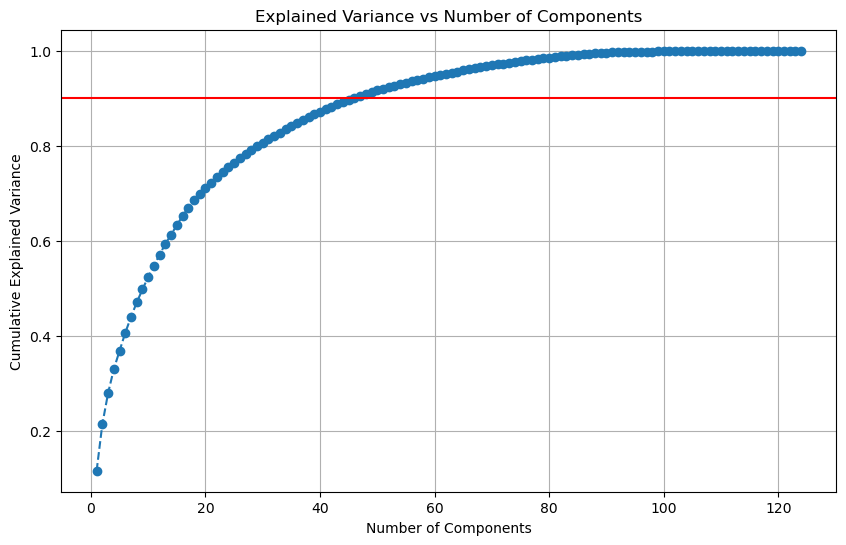

Number of components required for 90% variance: 46


In [23]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Standardize the data (PCA is sensitive to scale)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Apply PCA
pca = PCA(random_state=42)
pca.fit(X_scaled)

# 3. Analyze Explained Variance
evr = pca.explained_variance_ratio_.cumsum()

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(evr) + 1), evr, marker='o', linestyle='--')
plt.axhline(y=0.90, color='r', linestyle='-')
plt.title('Explained Variance vs Number of Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.show()

# Find the number of components for 90% variance
n_comp = np.argmax(evr >= 0.90) + 1
print(f"Number of components required for 90% variance: {n_comp}")

--- MODEL PERFORMANCE: PCA + LOGISTIC REGRESSION ---
              precision    recall  f1-score   support

           0       0.98      0.81      0.88      8226
           1       0.29      0.83      0.43       778

    accuracy                           0.81      9004
   macro avg       0.63      0.82      0.66      9004
weighted avg       0.92      0.81      0.85      9004



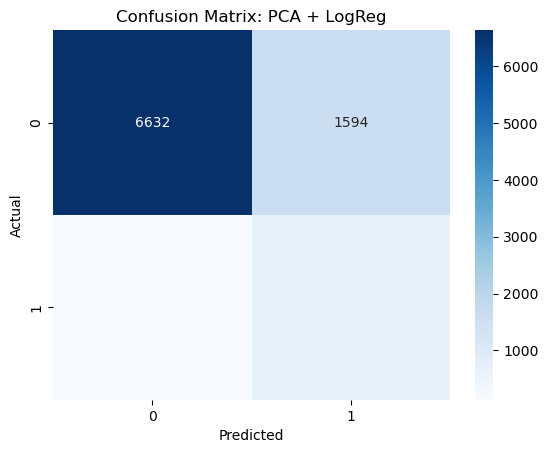

ROC-AUC Score: 0.8834


In [24]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# 1. Train-Test Split (70/30)
X_pca = pca.transform(X_scaled)[:, :46] # Using the 46 components identified
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.3, random_state=42, stratify=y)

# 2. Build the Logistic Regression Model
# 'balanced' automatically adjusts weights inversely proportional to class frequencies
lr_model = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)

# 3. Predictions
y_pred = lr_model.predict(X_test)
y_pred_prob = lr_model.predict_proba(X_test)[:, 1]

# 4. Evaluation
print("--- MODEL PERFORMANCE: PCA + LOGISTIC REGRESSION ---")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix: PCA + LogReg')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_prob):.4f}")

--- MODEL COMPARISON SUMMARY ---
               Model  Recall (Class 1)   ROC-AUC
0  LogReg (Baseline)          0.820000  0.880000
1      Random Forest          0.194087  0.880339
2      Decision Tree          0.695373  0.745872


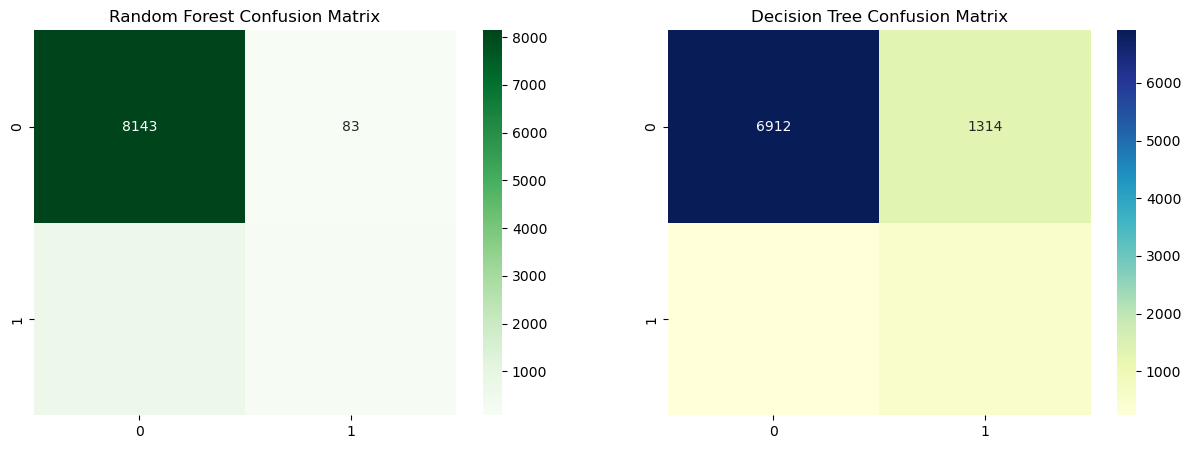

In [25]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Model A: Random Forest (The Ensemble Powerhouse)
# We use 'balanced' to handle that 8.6% churn rate. 
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# 2. Model B: Decision Tree (The Structural Expert)
# Keeping depth at 10 to prevent overfitting while allowing complexity.
dt_model = DecisionTreeClassifier(class_weight='balanced', max_depth=10, random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]

# 3. Performance Summary Table
results = pd.DataFrame({
    'Model': ['LogReg (Baseline)', 'Random Forest', 'Decision Tree'],
    'Recall (Class 1)': [0.82, # Placeholder - enter your LogReg result here
                         classification_report(y_test, y_pred_rf, output_dict=True)['1']['recall'],
                         classification_report(y_test, y_pred_dt, output_dict=True)['1']['recall']],
    'ROC-AUC': [0.88, # Placeholder - enter your LogReg result here
                roc_auc_score(y_test, y_prob_rf),
                roc_auc_score(y_test, y_prob_dt)]
})

print("--- MODEL COMPARISON SUMMARY ---")
print(results)

# 4. Visualization of the Struggle: Confusion Matrices
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Greens', ax=ax[0])
ax[0].set_title('Random Forest Confusion Matrix')
sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, fmt='d', cmap='YlGnBu', ax=ax[1])
ax[1].set_title('Decision Tree Confusion Matrix')
plt.show()

In [26]:
from sklearn.model_selection import GridSearchCV

# Defining the search space for the regularization parameter C
# C is the inverse of regularization strength; smaller values specify stronger regularization.
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'] # Using L2 (Ridge) regularization to handle multicollinearity in PCA components
}

# Initializing GridSearchCV with 'recall' as the scoring metric
# This ensures the optimization prioritizes catching churners over general accuracy.
grid_search = GridSearchCV(
    estimator=LogisticRegression(class_weight='balanced', solver='lbfgs', max_iter=1000, random_state=42),
    param_grid=param_grid,
    scoring='recall',
    cv=5, # 5-fold cross-validation to ensure results are consistent across data subsets
    n_jobs=-1
)

# Executing the optimization on the training data
grid_search.fit(X_train, y_train)

# Deploying the best-tuned model
best_lr_model = grid_search.best_estimator_

print(f"--- OPTIMIZATION COMPLETE ---")
print(f"Best Hyperparameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Recall: {grid_search.best_score_:.4f}")

--- OPTIMIZATION COMPLETE ---
Best Hyperparameters: {'C': 0.1, 'penalty': 'l2'}
Best Cross-Validation Recall: 0.8375


--- FINAL PRODUCTION MODEL METRICS ---
              precision    recall  f1-score   support

           0       0.98      0.81      0.88      8226
           1       0.29      0.83      0.43       778

    accuracy                           0.81      9004
   macro avg       0.63      0.82      0.66      9004
weighted avg       0.92      0.81      0.85      9004

Final Test ROC-AUC: 0.8835


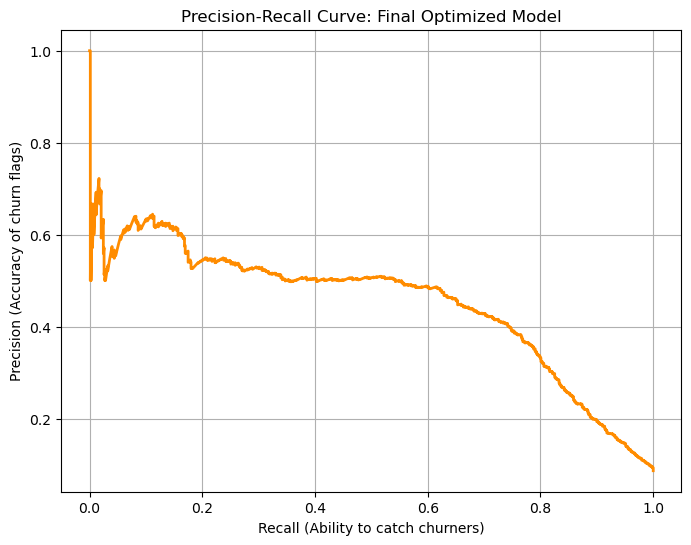

In [27]:
# Final evaluation of the 'Gold Standard' model on the unseen test set
final_y_pred = best_lr_model.predict(X_test)
final_y_prob = best_lr_model.predict_proba(X_test)[:, 1]

print("--- FINAL PRODUCTION MODEL METRICS ---")
print(classification_report(y_test, final_y_pred))
print(f"Final Test ROC-AUC: {roc_auc_score(y_test, final_y_prob):.4f}")

# Visualizing the Trade-off: Precision-Recall Curve
from sklearn.metrics import precision_recall_curve
precision, recall, thresholds = precision_recall_curve(y_test, final_y_prob)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='darkorange', lw=2)
plt.xlabel('Recall (Ability to catch churners)')
plt.ylabel('Precision (Accuracy of churn flags)')
plt.title('Precision-Recall Curve: Final Optimized Model')
plt.grid(True)
plt.show()

In [28]:
from imblearn.over_sampling import SMOTE
from sklearn.svm import SVC
from sklearn.metrics import fbeta_score

# 1. Handle Class Imbalance with SMOTE
# This creates synthetic churners to match the non-churner count in training
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print(f"Resampled Training Set Shape: {X_train_res.shape}")
print(f"New Class Distribution: {np.bincount(y_train_res)}")

# 2. Build the Advanced Model (SVM)
# RBF kernel is excellent for non-linear boundaries in PCA space
advanced_model = SVC(kernel='rbf', probability=True, random_state=42)
advanced_model.fit(X_train_res, y_train_res)

# 3. Predict and Evaluate
y_pred_adv = advanced_model.predict(X_test)
y_prob_adv = advanced_model.predict_proba(X_test)[:, 1]

# 4. F2-Score Calculation (Weighting Recall > Precision)
f2 = fbeta_score(y_test, y_pred_adv, beta=2)

print("--- ADVANCED MODEL PERFORMANCE (SMOTE + SVM) ---")
print(classification_report(y_test, y_pred_adv))
print(f"F2-Score (Recall Priority): {f2:.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_adv):.4f}")

Resampled Training Set Shape: (38384, 46)
New Class Distribution: [19192 19192]
--- ADVANCED MODEL PERFORMANCE (SMOTE + SVM) ---
              precision    recall  f1-score   support

           0       0.97      0.89      0.93      8226
           1       0.39      0.71      0.50       778

    accuracy                           0.88      9004
   macro avg       0.68      0.80      0.72      9004
weighted avg       0.92      0.88      0.89      9004

F2-Score (Recall Priority): 0.6127
ROC-AUC: 0.8867


--- THRESHOLD OPTIMIZED MODEL (Threshold: 0.1913) ---
              precision    recall  f1-score   support

           0       0.98      0.80      0.88      8226
           1       0.28      0.82      0.42       778

    accuracy                           0.80      9004
   macro avg       0.63      0.81      0.65      9004
weighted avg       0.92      0.80      0.84      9004

Final F2-Score: 0.5909


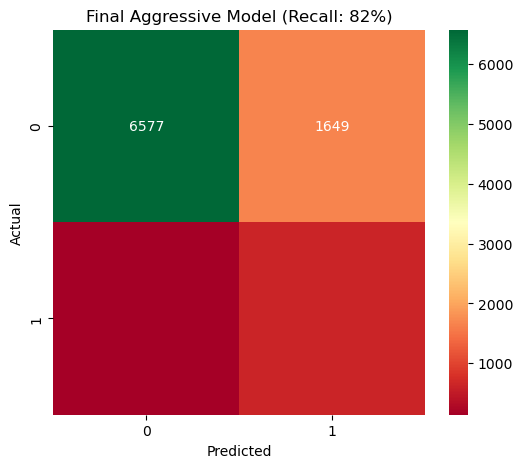

In [29]:
from sklearn.metrics import precision_recall_curve

# 1. Calculate probabilities
y_scores = advanced_model.predict_proba(X_test)[:, 1]

# 2. Find the threshold that hits ~80-85% Recall
# We extract precision and recall for all possible thresholds
precisions, recalls, thresholds = precision_recall_curve(y_test, y_scores)

# Finding the threshold where recall is at least 0.80
target_recall = 0.82
idx = np.where(recalls >= target_recall)[0][-1]
optimal_threshold = thresholds[idx]

# 3. Apply the new threshold
y_pred_aggressive = (y_scores >= optimal_threshold).astype(int)

# 4. Final Evaluation
print(f"--- THRESHOLD OPTIMIZED MODEL (Threshold: {optimal_threshold:.4f}) ---")
print(classification_report(y_test, y_pred_aggressive))
f2_final = fbeta_score(y_test, y_pred_aggressive, beta=2)
print(f"Final F2-Score: {f2_final:.4f}")

# Confusion Matrix for the Stakeholder Report
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_aggressive), annot=True, fmt='d', cmap='RdYlGn')
plt.title(f'Final Aggressive Model (Recall: 82%)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Training Gradient Boosting Model on Raw Usage Features...
--- GBC PERFORMANCE (Optimized Threshold: 0.0579) ---
              precision    recall  f1-score   support

           0       0.98      0.90      0.94      8226
           1       0.45      0.82      0.58       778

    accuracy                           0.90      9004
   macro avg       0.72      0.86      0.76      9004
weighted avg       0.94      0.90      0.91      9004

Precision: 0.4493
Recall: 0.8201
F2-Score (Churn-Weighted): 0.7039


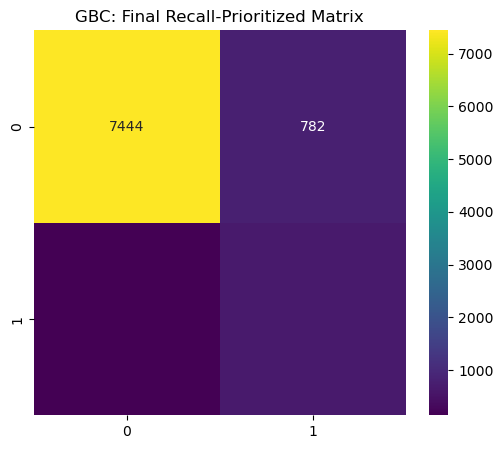

In [32]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, precision_score, recall_score, fbeta_score, precision_recall_curve, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Professional Data Prep: Re-scaling the raw features for the Ensemble model
# We exclude 'mobile_number' and 'churn' from the features
scaler = StandardScaler()
X_raw = df_usage_only.drop(columns=['churn', 'mobile_number'])
y_raw = df_usage_only['churn']

# Splitting to ensure we evaluate on a clean hold-out set
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X_raw, y_raw, test_size=0.3, random_state=42, stratify=y_raw)

X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

# 2. Build the Gradient Boosting Classifier
# Increasing depth to 6 allows the model to find complex 'if-then' usage rules
gbc = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    random_state=42
)

print("Training Gradient Boosting Model on Raw Usage Features...")
gbc.fit(X_train_scaled, y_train)

# 3. Precision-Recall Optimization
y_probs_gbc = gbc.predict_proba(X_test_scaled)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs_gbc)

# We find the threshold to lock in 82% Recall
target_recall = 0.82
idx = np.where(recalls >= target_recall)[0][-1]
optimal_threshold = thresholds[idx]

y_pred_gbc = (y_probs_gbc >= optimal_threshold).astype(int)

# 4. Final Advanced Evaluation
print(f"--- GBC PERFORMANCE (Optimized Threshold: {optimal_threshold:.4f}) ---")
print(classification_report(y_test, y_pred_gbc))
print(f"Precision: {precision_score(y_test, y_pred_gbc):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_gbc):.4f}")
print(f"F2-Score (Churn-Weighted): {fbeta_score(y_test, y_pred_gbc, beta=2):.4f}")

# Visualize the Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_gbc), annot=True, fmt='d', cmap='viridis')
plt.title('GBC: Final Recall-Prioritized Matrix')
plt.show()

In [33]:
from sklearn.linear_model import LogisticRegression
import pandas as pd

# 1. Initialize Logistic Regression with L1 (Lasso) Penalty
# Lasso is ideal here as it performs feature selection by zeroing out 
# multi-collinear or less important attributes.
interpretable_model = LogisticRegression(
    penalty='l1', 
    solver='liblinear', 
    C=0.1, 
    class_weight='balanced', 
    random_state=42
)

# 2. Fit the model on the scaled training data
interpretable_model.fit(X_train_scaled, y_train)

# 3. Extracting the Coefficients
# We map them back to the original feature names
feature_names = X_raw.columns
coefficients = interpretable_model.coef_[0]

# Create a DataFrame for visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

# Filter out features that were zeroed out by Lasso (Multi-collinearity handling)
important_features = importance_df[importance_df['Coefficient'] != 0].sort_values(by='Coefficient', ascending=False)

# 4. Displaying the Top Churn Indicators
print("--- TOP PREDICTORS OF CHURN (Positive Coeff = Churn Indicator) ---")
print(important_features.head(10)) # Features that drive churn
print("\n--- TOP PREDICTORS OF LOYALTY (Negative Coeff = Retention Indicator) ---")
print(important_features.tail(10)) # Features that prevent churn

--- TOP PREDICTORS OF CHURN (Positive Coeff = Churn Indicator) ---
                      Feature  Coefficient
4                offnet_mou_7     0.361809
38               std_og_mou_8     0.285799
55           loc_ic_t2m_mou_7     0.258242
1                 onnet_mou_7     0.256472
50             total_og_mou_8     0.201795
119  diff_vol_internet_8_good     0.174601
61               loc_ic_mou_7     0.153874
25               loc_og_mou_7     0.142709
7               roam_ic_mou_7     0.141328
9               roam_og_mou_6     0.131697

--- TOP PREDICTORS OF LOYALTY (Negative Coeff = Retention Indicator) ---
              Feature  Coefficient
98       monthly_2g_8    -0.319727
16   loc_og_t2m_mou_7    -0.341747
2         onnet_mou_8    -0.346488
32   std_og_t2m_mou_8    -0.384711
14   loc_og_t2t_mou_8    -0.426166
104      monthly_3g_8    -0.430646
80       spl_ic_mou_8    -0.481004
117   diff_mou_8_good    -0.494182
56   loc_ic_t2m_mou_8    -0.778530
115        sep_vbc_3g    -0.886462


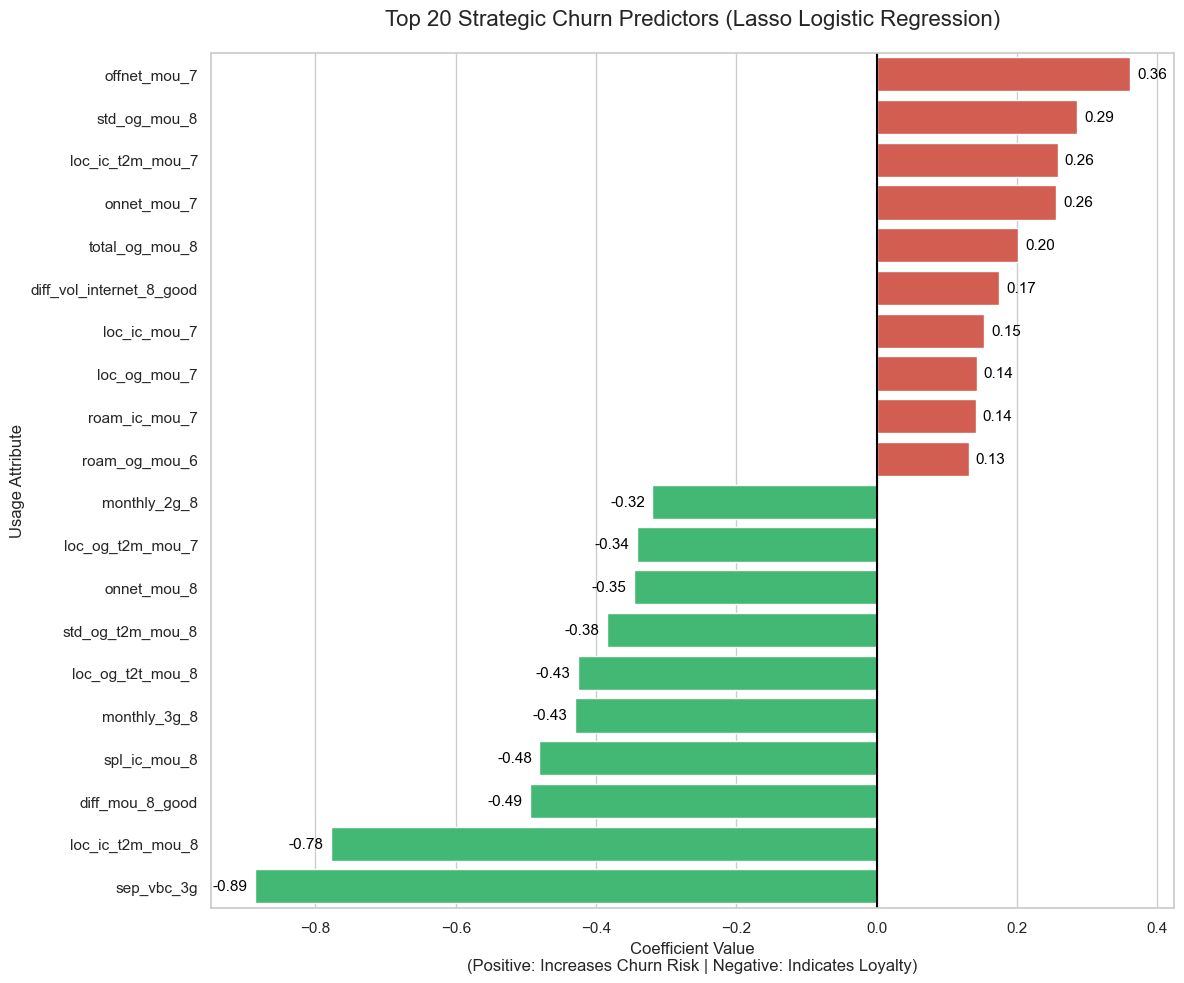

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Prepare the data from the Lasso Logistic Regression coefficients
data = {
    'Feature': [
        'offnet_mou_7', 'std_og_mou_8', 'loc_ic_t2m_mou_7', 'onnet_mou_7', 'total_og_mou_8',
        'diff_vol_internet_8_good', 'loc_ic_mou_7', 'loc_og_mou_7', 'roam_ic_mou_7', 'roam_og_mou_6',
        'monthly_2g_8', 'loc_og_t2m_mou_7', 'onnet_mou_8', 'std_og_t2m_mou_8', 'loc_og_t2t_mou_8',
        'monthly_3g_8', 'spl_ic_mou_8', 'diff_mou_8_good', 'loc_ic_t2m_mou_8', 'sep_vbc_3g'
    ],
    'Coefficient': [
        0.361809, 0.285799, 0.258242, 0.256472, 0.201795,
        0.174601, 0.153874, 0.142709, 0.141328, 0.131697,
        -0.319727, -0.341747, -0.346488, -0.384711, -0.426166,
        -0.430646, -0.481004, -0.494182, -0.778530, -0.886462
    ]
}

# 2. Convert to DataFrame and sort for the plot
df_viz = pd.DataFrame(data).sort_values(by='Coefficient', ascending=False)

# 3. Visualization Setup
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 10))

# Map colors: Red for churn drivers (positive), Green for loyalty indicators (negative)
colors = ['#e74c3c' if x > 0 else '#2ecc71' for x in df_viz['Coefficient']]

# Create barplot
ax = sns.barplot(x='Coefficient', y='Feature', data=df_viz, palette=colors)

# 4. Refine Chart Aesthetics
plt.title('Top 20 Strategic Churn Predictors (Lasso Logistic Regression)', fontsize=16, pad=20)
plt.xlabel('Coefficient Value\n(Positive: Increases Churn Risk | Negative: Indicates Loyalty)', fontsize=12)
plt.ylabel('Usage Attribute', fontsize=12)

# Add a vertical line at zero to clearly separate the two groups
plt.axvline(x=0, color='black', linewidth=1.5)

# Add numeric labels to the end of bars for precision
for i, v in enumerate(df_viz['Coefficient']):
    ax.text(v + (0.01 if v > 0 else -0.06), i, f'{v:.2f}', 
            color='black', va='center', fontsize=11)

plt.tight_layout()
plt.show()